In [8]:
%pip install pandas numpy matplotlib
! pip intsall pandas 
! pip install numpy
! pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: unknown command "intsall" - maybe you meant "install"

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


--- LVMH (2010 - 2023) Return Analysis ---
Total Return: 1112.44%
CAGR: 19.54%


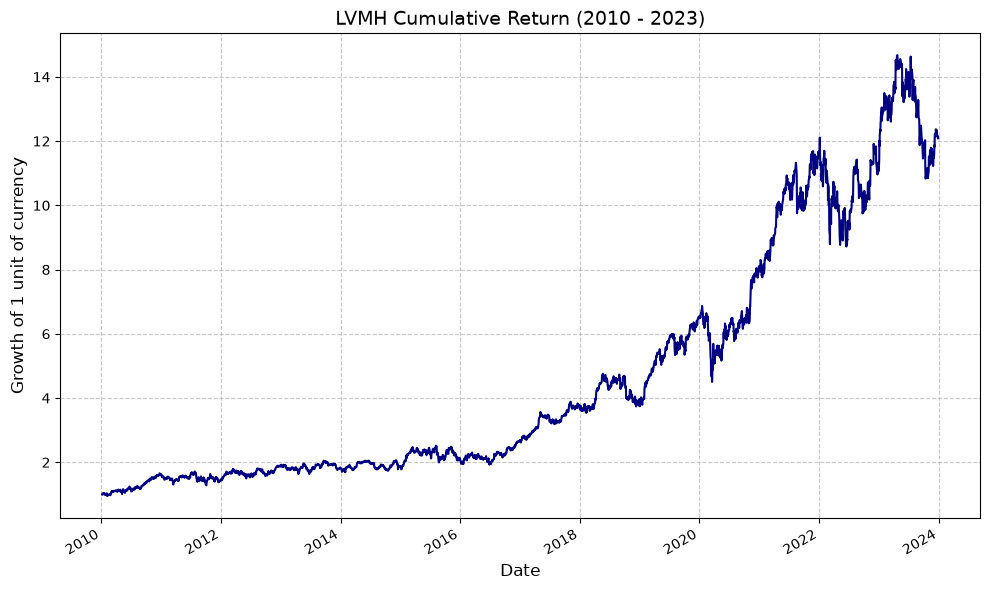

--- LVMH Violately ---
2010-2023
Annual Volatility: 27.10%


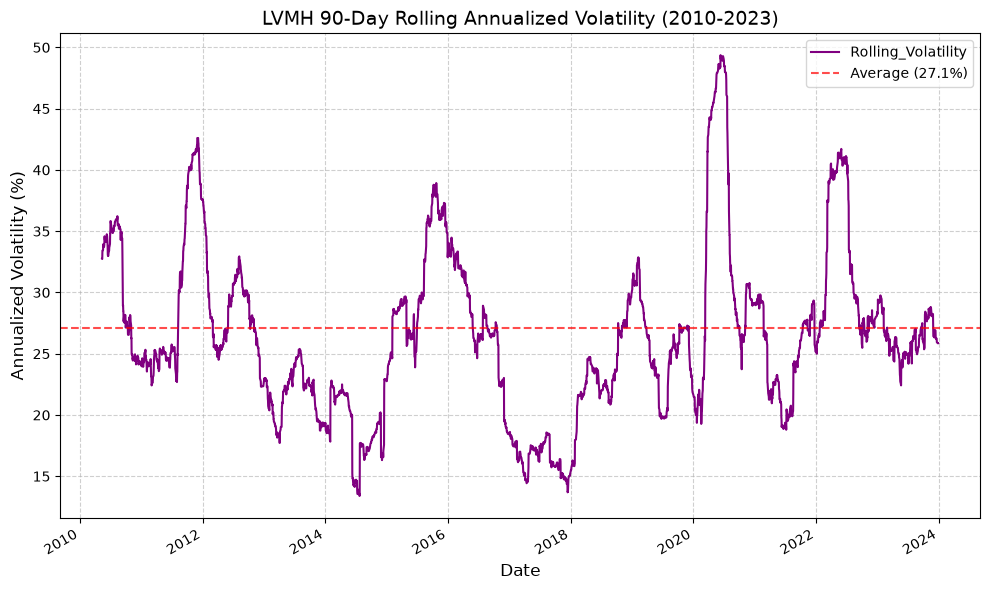

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Load data and prepare analysis period
data_file = Path('../DATA/LV.csv')
if not data_file.exists():
    # try searching the repo for LV.csv
    matches = list(Path.cwd().rglob('LV.csv'))
    if matches:
        data_file = matches[0]

if not data_file.exists():
    raise FileNotFoundError(f"Cannot find LV.csv. Current working dir: {Path.cwd()}")

df = pd.read_csv(data_file, parse_dates=['Date'], index_col='Date')
df = df.sort_index()
df_period = df.loc['2010-01-01':'2023-12-31'].copy()

# calculate close price
df_period['Daily_Return'] = df_period['Close'].pct_change()
df_period['Cumulative_Return'] = (1 + df_period['Daily_Return']).cumprod()
start_price = df_period['Close'].iloc[0] #first day price in 2010
end_price = df_period['Close'].iloc[-1] # end of day price in 2023

# calculate how many years
days_passed = (df_period.index[-1]- df_period.index[0]).days
years = days_passed / 365.25

# calculate total return and compound annual growth rate
total_return = (end_price / start_price -1)* 100
cagr = ((end_price / start_price) ** (1 / years) - 1) * 100

print(f"--- LVMH (2010 - 2023) Return Analysis ---")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")

# Asset growth plot
df_period['Cumulative_Return'].plot(figsize=(10, 6), color='navy', linewidth=1.5)
plt.title('LVMH Cumulative Return (2010 - 2023)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth of 1 unit of currency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#calculate volatility
annual_volatility = df_period['Daily_Return'].std() * np.sqrt(252)
print(f"--- LVMH Volatility ---")
print(f"2010-2023")
print(f"Annual Volatility: {annual_volatility * 100:.2f}%")

#Rolling Volatility
window_size = 90 #selecting 90 days as a season
df_period['Rolling_Volatility'] = df_period['Daily_Return'].rolling(window=window_size).std() * np.sqrt(252)
plt.figure(figsize=(10, 6))

# Multiply the decimal by 100 to convert it into a percentage
(df_period['Rolling_Volatility'] * 100).plot(color='purple', linewidth=1.5)
plt.title(f'LVMH {window_size}-Day Rolling Annualized Volatility (2010-2023)', fontsize=14)
plt.ylabel('Annualized Volatility (%)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.axhline(annual_volatility * 100, color='red', linestyle='--', alpha=0.7, label=f'Average ({annual_volatility*100:.1f}%)')
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6) 
plt.tight_layout()
plt.show()


LV date range: 2010-01-04 00:00:00 to 2023-12-29 00:00:00
GSPC date range: 2010-01-04 00:00:00 to 2018-06-06 00:00:00
Combined data range after dropna: 2010-01-04 00:00:00 to 2018-06-06 00:00:00
Total rows: 2099


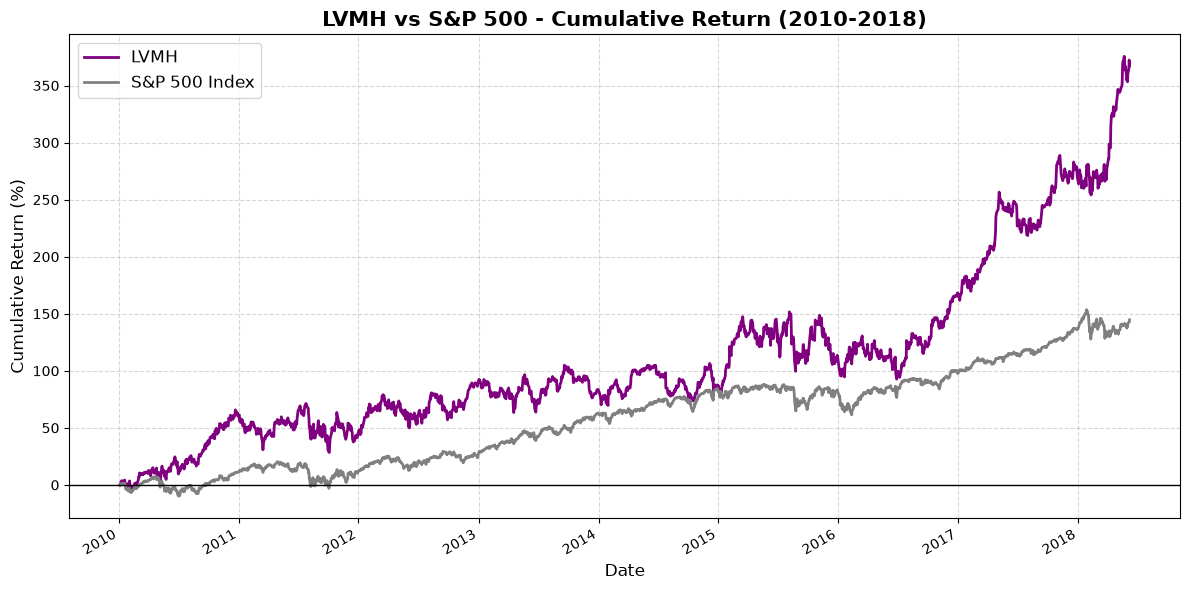


LVMH Total Return (2010-2018): 367.29%
S&P 500 Total Return (2010-2018): 144.69%


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# use the already-loaded dataframe to avoid FileNotFoundError
lv_df = df.copy()

# Load GSPC data with proper path
gspc_file = Path('../DATA/GSPC.csv')
gspc_df = pd.read_csv(gspc_file, parse_dates=['Date'], index_col='Date')

lv_df = lv_df.loc['2010-01-01':'2023-12-31'].sort_index()
gspc_df = gspc_df.loc['2010-01-01':'2023-12-31'].sort_index()

print(f"LV date range: {lv_df.index.min()} to {lv_df.index.max()}")
print(f"GSPC date range: {gspc_df.index.min()} to {gspc_df.index.max()}")

compare_df = pd.DataFrame({
    'LVMH': lv_df['Close'],
    'S&P 500': gspc_df['Close']
}).dropna()

print(f"Combined data range after dropna: {compare_df.index.min()} to {compare_df.index.max()}")
print(f"Total rows: {len(compare_df)}")

compare_df['LVMH_Growth'] = compare_df['LVMH'] / compare_df['LVMH'].iloc[0]
compare_df['SP500_Growth'] = compare_df['S&P 500'] / compare_df['S&P 500'].iloc[0]
lvmh_total = (compare_df['LVMH_Growth'].iloc[-1] - 1) * 100
sp500_total = (compare_df['SP500_Growth'].iloc[-1] - 1) * 100

plt.figure(figsize=(12, 6))
((compare_df['LVMH_Growth'] - 1) * 100).plot(color='purple', label='LVMH', linewidth=2)
((compare_df['SP500_Growth'] - 1) * 100).plot(color='gray', label='S&P 500 Index', linewidth=2)
plt.title('LVMH vs S&P 500 - Cumulative Return (2010-2018)', fontsize=15, fontweight='bold')
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', fontsize=12) 
plt.grid(True, linestyle='--', alpha=0.5) 
plt.axhline(0, color='black', linewidth=1) 
plt.tight_layout()
plt.show()

print(f"\nLVMH Total Return (2010-2018): {lvmh_total:.2f}%")
print(f"S&P 500 Total Return (2010-2018): {sp500_total:.2f}%")
